# ENCS5342 Final Project - Track 1
## Part-of-Speech (POS) Tagging

| | |
|---|---|
| **Course** | ENCS5342 — Information Retrieval with Applications of NLP |
| **Instructor** | Dr. Ahmed I. A. Shawahna — Birzeit University |
| **Semester** | Second Semester 2025–2026 |

<br>
   
| | Name | ID | Section |
|---|---|---|---|
| **Student 1** | Aysha Hasan  | 1220352 | Sec1 | 
| **Student 2** | Besan Maaly  | 1222776 | Sec1 | 


**Dataset:** English Penn Treebank in CoNLL format  
**Task:** Predict joint POS tags by combining coarse and fine POS tags, such as `NOUN-NNP` and `VERB-VBD`.


***

### 1. Abstract

Part-of-Speech (POS) tagging is a foundational sequence labeling task in Natural Language Processing (NLP) that serves as a critical component for downstream text-processing pipelines. In this project, we implemented and evaluated an end-to-end POS tagging system for English using the **Penn Treebank** corpus in CoNLL format. We developed and compared two distinct architectures built entirely from scratch: a probabilistic baseline using a **Hidden Markov Model (HMM)** with Viterbi decoding, and a deep learning approach utilizing a **Bidirectional Long Short-Term Memory (BiLSTM)** network. 

To ensure model stability and prevent overfitting, we integrated advanced engineering techniques into the neural training loop, including **Dropout regularization**, **Gradient Clipping**, and **Early Stopping**. Our quantitative results show that both models achieved high performance, with the HMM (95.51%) slightly outperforming the BiLSTM (95.12%) on the development set, despite the neural model's higher learning capacity during training. Finally, we conducted a detailed error analysis using micro and macro-averaged F1 scores to highlight the performance gap caused by dataset imbalance across the 46 joint POS tags.

---

### 2. Individual Contribution Statement

To ensure a successful implementation of this project, we divided the responsibilities according to our strengths in data engineering and neural architecture design:

*   **Aysha Hasan (1220352):**
    *   **Data Engineering:** Responsible for the core data parsing logic and CoNLL file processing.
    *   **Vocabulary Management:** Built the dictionary mappings for both words and joint POS tags (vocab and tag2idx).
    *   **Evaluation Module:** Implemented the joint token-level prediction evaluation module.
    *   **Reporting:** Generated the comprehensive per-class validation tables and comparative performance reports.

*   **Besan Maaly (1222776):**
    *   **Dataset Structures:** Built the custom PyTorch Dataset and DataLoader classes, including the sequence collate functions.
    *   **Neural Architecture:** Designed and implemented the modular BiLSTMTagger architecture and training loop.
    *   **Optimization Logic:** Integrated regularized training techniques, including Early Stopping, Dropout, and Gradient Clipping.
    *   **Model Tuning:** Managed the hyperparameter configuration and loss function masking for padding tokens.

***

## 2. Introduction

### 2.1 Motivation and Background
Part-of-Speech (POS) tagging is the process of assigning a specific grammatical category—such as noun, verb, adjective, or preposition—to every token within a sentence. It serves as a foundational pipeline component in Natural Language Processing (NLP), acting as a crucial prerequisite for many higher-level language understanding systems. Accurate POS tags significantly enhance the performance of several downstream NLP tasks, including syntactic dependency parsing, named entity recognition (NER), information extraction, semantic search disambiguation, and machine translation.

Despite its straightforward definition, POS tagging presents a non-trivial contextual disambiguation challenge. A major difficulty arises because the exact same word form can belong to completely different grammatical categories depending entirely on its surrounding context; for instance, the word "book" functions as a verb in "book a flight" but acts as a noun in "read a book". Furthermore, processing real-world text introduces severe linguistic challenges, such as handling rare or unseen words, dealing with complex named entities, and adapting to domain-specific vocabularies that distort fixed lexicon mappings.

### 2.2 Project Goals and Research Questions
The primary objective of this project is to own the entire NLP engineering pipeline from scratch—moving from raw data parsing to robust model training and comprehensive evaluation rather than delegating core tasks to pre-built high-level APIs. This project aims to implement and rigorously compare two distinct paradigms for sequence labeling: a classical probabilistic baseline and a modern deep learning model. 

Additionally, this work explores critical machine learning research questions regarding model regularization:
1. **Regularization & Stability:** How effective are engineering techniques like Early Stopping and Gradient Clipping in preventing overfitting and stabilizing the BiLSTM model when training on full text datasets?
2. **Handling Data Imbalance:** How well does the deep learning sequence model (BiLSTM) handle highly skewed and imbalanced POS tags compared to the traditional statistical model (HMM)? 

### 2.3 Key Contributions
Our team's concrete contributions to the implementation of this end-to-end POS tagging pipeline include:
* **Data Processing & Pipeline Setup:** Successfully parsed the structural column-based CoNLL dataset format and dynamically mapped the structural inputs to construct joint targets by merging coarse-grained and fine-grained POS labels for example(`NOUN-NNP`, `VERB-VBD`).

* **Neural Architecture Development:** Designed and trained a deep learning BiLSTM neural tagger using PyTorch, incorporating explicit sequence masking for padding tokens (`ignore_index=0`) and integrating dynamic training lifecycle techniques like Early Stopping, Dropout, and Gradient Clipping.
* **Comprehensive Evaluation Matrix:** Evaluated both systems using a strict framework consisting of token-level accuracy, per-class metrics (Precision, Recall, F1-score), and a comparative study between micro-averaged and macro-averaged scores to expose model behavior on highly skewed, rare linguistic tag classes.

## 3. Prior & Related Work

### 3.1 Overview of the Landmark Work
Sequence labeling tasks, particularly Part-of-Speech (POS) tagging, have evolved significantly from statistical rule-based systems to modern deep neural architectures. A landmark paper in this domain is by **Huang, Xu, and Yu (2015), titled "Bidirectional LSTM-CRF Models for Sequence Tagging."** which marked a significant advancement in sequence tagging tasks within Natural Language Processing (NLP). The paper proposed a variety of models based on Long Short-Term Memory (LSTM) networks, including standard LSTM, Bidirectional LSTM (BI-LSTM), LSTM with a Conditional Random Field (CRF) layer, and the combined BI-LSTM-CRF model. Their work was pioneering as it was the first to apply the BI-LSTM-CRF model to benchmark sequence tagging datasets in NLP. The model demonstrated superior capability in leveraging both past and future input features through its BI-LSTM component, while also utilizing sentence-level tag information via the CRF layer to ensure label consistency. The BI-LSTM-CRF model achieved state-of-the-art (or near state-of-the-art) accuracy on Part-of-Speech (POS) tagging, chunking, and Named Entity Recognition (NER) datasets, exhibiting reduced reliance on word embeddings compared to prior models. This architectural innovation subsequently became a standard baseline for numerous sequence labeling tasks in NLP.

### 3.2 Connection and Differences to Our Project
Our project directly connects to the foundational concepts introduced by Huang et al. (2015), as we implement a Bidirectional LSTM network to model text sequences from both directions to resolve linguistic ambiguities (such as identifying whether "book" is a noun or a verb based on surrounding context). 

However, our pipeline differs from and is simpler than the published work in several engineering aspects:
1. **Simplified Output Layer:** Instead of using a complex, computationally expensive CRF layer for joint global decoding, our neural tagger utilizes a straightforward linear layer (`nn.Linear`) combined with a Cross-Entropy Loss function to predict token-level tags directly. 
2. **From-Scratch Word Embeddings:** While professional architectures often rely on pre-trained word embeddings (like GloVe) or multi-level features (such as Character-level CNNs/LSTMs) to handle rare words, our project constructs its vocabulary dictionaries and lookup embeddings entirely from scratch utilizing only the joint training data provided in the CoNLL dataset.
3. **Probabilistic Baseline Comparison:** Unlike the purely neural focus of the paper, our work introduces a hand-built Hidden Markov Model (HMM) baseline with Viterbi decoding to measure the exact performance gain achieved when shifting from statistical transition probabilities to deep sequence learning.

## 4. Model



### 4.1 Hidden Markov Model Baseline

The first model is a Hidden Markov Model (HMM) baseline. It models POS tagging as a sequence labeling problem where each hidden state is a joint POS tag and each observed symbol is a word token.

For a sentence $w_1, \dots, w_n$ and tag sequence $t_1, \dots, t_n$, the HMM uses three probability tables estimated from the training set:

- Initial probabilities: $\pi(t) = P(t_1=t)$
- Transition probabilities: $A(t_i \mid t_{i-1})$
- Emission probabilities: $B(w_i \mid t_i)$

The implementation applies additive smoothing to transition and emission probabilities. Rare training words are mapped to feature-based unknown classes such as UNK-CAP, UNK-ING, UNK-NUM, and UNK-HYPH, which gives the model a better fallback for unseen development words. Decoding is performed with the Viterbi algorithm in log space to avoid numerical underflow.


In [25]:
import sys
import os
# Change the search path by going back one step and entering the src folder to access pipeline modules
sys.path.append(os.path.abspath(os.path.join("..", "src")))

from data_loader import load_conll, get_vocab_and_tag_sets
from vocab import build_word2idx, build_tag2idx
from hmm_baseline import HMMTagger, explain_sentence_log
from viterbi import viterbi, predict



***

### 4.2 Our BiLSTM Neural Tagger

For the second part of our project, we implemented a **BiLSTM (Bidirectional Long Short-Term Memory)** architecture. While the HMM we built earlier is great, the BiLSTM is much more powerful for POS tagging because it doesn't just look at the previous word—it looks at the entire sentence (both past and future context) before deciding on a tag.

#### 4.2.1 How the Model is Structured

We built the model using three main layers:

1.  **The Embedding Layer**: This is where we turn our word indices into dense vectors ($e_i$). Instead of just using raw numbers, these embeddings help the model understand the relationships between different words.
2.  **The BiLSTM Layer**: This is the "brain" of the model. It processes the embeddings in two directions at once:
    *   **Forward ($\overrightarrow{h_i}$)**: Reading the sentence from start to finish.
    *   **Backward ($\overleftarrow{h_i}$)**: Reading the sentence from finish to start.
    *   **The Result**: We concatenate these two views together ($h_i = [\overrightarrow{h_i}; \overleftarrow{h_i}]$) so each word has a "context-rich" representation.
3.  **The Linear Layer**: Finally, we take that 256-dimensional hidden state and pass it through a linear transformation ($s_i = W h_i + b$) to get a score for each of our 46 possible POS tags.

#### 4.2.2 The Data Flow (Diagram)

If you're drawing this in your notes, the flow looks like this:
**Input Tokens** $\rightarrow$ **Embeddings** $\rightarrow$ **BiLSTM (Forward + Backward)** $\rightarrow$ **Linear Layer** $\rightarrow$ **Final Tag Scores**

#### 4.2.3 Engineering Tricks We Used

To make sure the model actually learned well and didn't just memorize the training data (overfitting), we applied a few standard ML engineering techniques:

| Technique | Why we used it |
| :--- | :--- |
| **Dropout** | We randomly "turned off" some neurons during training to force the model to be more robust. |
| **Early Stopping** | We watched the validation accuracy and stopped training as soon as it started to drop to prevent overfitting. |
| **Gradient Clipping** | We capped the gradients at a `max_norm` of 5.0 so the model wouldn't "explode" during backpropagation on long sentences. |
| **Weight Decay** | A form of L2 regularization to keep our weights small and the model simple. |
| **Padding Masking** | We used `ignore_index=0` in our loss function so that the extra `<PAD>` tokens wouldn't mess up our accuracy or loss calculations. |

In [26]:
from bilstm_model import BiLSTMTagger
from train_utils import POSDataset, collate_fn
from train_bilstm import train_model
print("BiLSTM modules imported successfully")

BiLSTM modules imported successfully


## 5. Data

### 5.1 Dataset Description

The **English Penn Treebank** corpus was utilized for this project. This dataset is a standard benchmark in the field of Natural Language Processing and was provided in the CoNLL column-based format. Two primary files were used for the implementation: the training set, which contains 37,840 sentences, and the development set, which consists of 1,992 sentences. The training set was used to build the models, while the development set allowed hyperparameter tuning and performance evaluation. There is also a withheld test set that the instructor is using for final grading.

A key requirement of this project was to predict a **joint POS tag**. Instead of using a single column, the coarse-grained (CPOS) and fine-grained (FPOS) tags from columns 4 and 5 of the CoNLL files were merged. For instance, a word like "Collins" would have its tags combined into `NOUN-NNP`. In total, this process resulted in 45 unique joint tags across the training data. The table below provides a breakdown of the dataset files and their purposes:

| Dataset File | Sentence Count | Primary Purpose |
| :--- | :--- | :--- |
| `en-universal-train.conll` | 37,840 | Training the HMM and BiLSTM models |
| `en-universal-dev.conll` | 1,992 | Hyperparameter tuning and validation |
| **Test Set** | — | Final evaluation (withheld by instructor) |

### 5.2 Preprocessing Pipeline

A **preprocessing pipeline** was developed to prepare the data for both models. First, the CoNLL files were parsed by reading them line by line, using blank lines to identify the end of each sentence. The joint tags were then constructed by merging the relevant columns. Next, two vocabulary mappings were built strictly from the training data: a `word2idx` map for the input words and a `tag2idx` map for the labels. Index 0 was reserved for `<PAD>` and index 1 for `<UNK>` (unknown) tokens.

Handling unknown words was particularly important for the **HMM** model. Singleton words — those appearing only once in the training set — were replaced with specialized feature-based classes such as `<UNK-CAP>` for capitalized words and `<UNK-NUM>` for numbers. This helps the model generalize better when encountering new words at inference time. For the **BiLSTM**, padding was applied to handle the varying lengths of sentences. Using PyTorch's `pad_sequence` function, all sentences in a batch were padded with `<PAD>` tokens to match the length of the longest sentence. The following table summarizes the final statistics of the processed data:

| Statistic | Value |
| :--- | :--- |
| **Total Training Sentences** | 37,840 |
| **Total Development Sentences** | 1,992 |
| **Vocabulary Size** | 43,359 (including `<PAD>` and `<UNK>`) |
| **Distinct Joint POS Tags** | 46 (including `<PAD>`) |
| **Singleton Words Processed** | ~20,260 |

In [27]:
# Basic setup
from pathlib import Path
import random
import numpy as np
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: c:\Users\az\Part-of-Speech-POS-Tagging
Data directory: c:\Users\az\Part-of-Speech-POS-Tagging\data


In [28]:
train_sentences = load_conll(DATA_DIR / "en-universal-train.conll")
dev_sentences = load_conll(DATA_DIR / "en-universal-dev.conll")

train_vocab, train_tags = get_vocab_and_tag_sets(train_sentences)
word2idx = build_word2idx(train_vocab)
tag2idx = build_tag2idx(train_tags)

print("Training sentences:", len(train_sentences))
print("Development sentences:", len(dev_sentences))
print("Vocabulary size including <PAD>/<UNK>:", len(word2idx))
print("Number of joint POS tags including <PAD>:", len(tag2idx))

words, tags = train_sentences[0]
print("\nFirst training sentence:")
for word, tag in zip(words, tags):
    print(f"{word:15s} -> {tag}")


Training sentences: 37840
Development sentences: 1992
Vocabulary size including <PAD>/<UNK>: 43359
Number of joint POS tags including <PAD>: 46

First training sentence:
In              -> ADP-IN
an              -> DET-DT
Oct.            -> NOUN-NNP
19              -> NUM-CD
review          -> NOUN-NN
of              -> ADP-IN
``              -> .-``
The             -> DET-DT
Misanthrope     -> NOUN-NN
''              -> .-''
at              -> ADP-IN
Chicago         -> NOUN-NNP
's              -> PRT-POS
Goodman         -> NOUN-NNP
Theatre         -> NOUN-NNP
(               -> .-(
``              -> .-``
Revitalized     -> VERB-VBN
Classics        -> NOUN-NNS
Take            -> VERB-VBP
the             -> DET-DT
Stage           -> NOUN-NN
in              -> ADP-IN
Windy           -> NOUN-NNP
City            -> NOUN-NNP
,               -> .-,
''              -> .-''
Leisure         -> NOUN-NN
&               -> CONJ-CC
Arts            -> NOUN-NNS
)               -> .-)
,              

In [29]:
from collections import Counter

def count_tokens(sentences):
    return sum(len(words) for words, _ in sentences)

def sentence_length_summary(sentences):
    lengths = np.array([len(words) for words, _ in sentences])
    return {
        "min": int(lengths.min()),
        "mean": float(lengths.mean()),
        "median": float(np.median(lengths)),
        "max": int(lengths.max()),
    }

tag_counter = Counter(tag for _, tags in train_sentences for tag in tags)

print("Train tokens:", count_tokens(train_sentences))
print("Dev tokens:", count_tokens(dev_sentences))
print("Unique train words:", len(train_vocab))
print("Unique joint POS tags:", len(train_tags))
print("Train sentence length summary:", sentence_length_summary(train_sentences))
print("Dev sentence length summary:", sentence_length_summary(dev_sentences))

print("\nMost frequent training tags:")
for tag, count in tag_counter.most_common(10):
    print(f"{tag:12s} {count}")


Train tokens: 902902
Dev tokens: 47126
Unique train words: 43357
Unique joint POS tags: 45
Train sentence length summary: {'min': 1, 'mean': 23.861046511627908, 'median': 23.0, 'max': 141}
Dev sentence length summary: {'min': 1, 'mean': 23.657630522088354, 'median': 23.0, 'max': 79}

Most frequent training tags:
NOUN-NN      126176
ADP-IN       102515
NOUN-NNP     87033
DET-DT       77723
ADJ-JJ       58227
NOUN-NNS     56900
.-,          46317
.-.          37506
NUM-CD       34775
ADV-RB       29382


## 6. Experiments

In this section, we'll go over the full experimental setup we used to test both our HMM baseline and the BiLSTM neural tagger. All of our experiments were run using the English Penn Treebank corpus, which was given to us in CoNLL format.

### 6.1 Data Splits

We divided the dataset into two standard parts for developing and evaluating our models:

| Dataset Split | File Name | Sentence Count | Purpose |
|---------------|-----------|----------------|---------|
| **Training Set** | `en-universal-train.conll` | 37,840 | This is what we used to train both our HMM and BiLSTM models. |
| **Development Set** | `en-universal-dev.conll` | 1,992 | We used this for tweaking hyperparameters and checking our models' performance during development. |

It's important to note that all the results we're showing for the development set are based on data our models hadn't seen during training. The instructor is holding onto a separate test set for the final evaluation after we submit our project.

### 6.2 HMM Baseline Hyperparameters

Our Hidden Markov Model acted as our probabilistic baseline. We set it up as a bigram tagger, using additive smoothing and Viterbi decoding.

**Smoothing Parameters:**
- **Emission Smoothing (`k_emission`):** We set this to 0.1. This helped us deal with word-tag combinations that weren't in our training data.
- **Transition Smoothing (`k_transition`):** Also 0.1. This was for handling tag-to-tag transitions we hadn't seen before.
- **Rare Word Threshold (`rare_threshold`):** We decided that any word appearing only once in the training data would be considered rare.

**Unknown Word Handling:**
To make our model better at handling words it hadn't seen, we mapped rare or completely new words to special feature-based unknown classes:
- `<UNK-CAP>`: For words that started with a capital letter.
- `<UNK-ING>`: For words ending in "ing."
- `<UNK-ED>`: For words ending in "ed."
- `<UNK-LY>`: For words ending in "ly."
- `<UNK-NUM>`: For words that contained numbers.
- `<UNK-HYPH>`: For words that had hyphens.
- `<UNK>`: This was our catch-all for any other unseen words.

**Decoding Algorithm:**
We used the **Viterbi algorithm**, which we implemented in log-space. This was a crucial step to prevent numerical underflow, which can happen with very small probabilities. The algorithm's job was to figure out the most likely sequence of tags for each sentence.

### 6.3 BiLSTM Neural Tagger Hyperparameters

Our deep learning model was a Bidirectional LSTM, which we built using PyTorch.

**Model Architecture:**

| Component | Configuration |
|-----------|---------------|
| **Embedding Layer** | We used 100-dimensional embeddings, which we trained from scratch. |
| **Padding Masking** | We set `padding_idx=0` to make sure padding tokens weren't included in the training calculations. |
| **BiLSTM Layer** | This had 1 layer, with 128 hidden units in each direction, making a total of 256. |
| **Output Layer** | A linear layer that mapped the output to our 46 joint POS tags. |

**Training Hyperparameters:**

| Hyperparameter | Value |
|----------------|-------|
| **Batch Size** | 32 |
| **Optimizer** | Adam |
| **Learning Rate** | 0.001 |
| **Epochs** | We ran it for 5 epochs, but with early stopping in place. |
| **Loss Function** | We used Cross-Entropy Loss, with `ignore_index=0` to ignore padding tokens. |

**Regularization and Stability Techniques:**
- **Gradient Clipping:** We applied this with a `max_norm` of 5.0. This was super important for preventing exploding gradients, especially when dealing with longer sentences during backpropagation.
- **Early Stopping:** We set a patience of 2 epochs. This meant if our validation accuracy didn't get better for two epochs in a row, we'd stop training to avoid overfitting.
- **Dropout:** This was automatically handled by the LSTM layer itself, active during training and off during evaluation.
- **Padding Masking:** We made sure to use this in our loss function so that padding tokens wouldn't mess with our gradients or loss calculations.

### 6.4 Evaluation Metrics

We put together a thorough evaluation framework to really understand how our models were doing. We knew that just looking at overall accuracy might hide problems with less common tags.

**Per-Class Metrics:**
- **Precision:** For each tag, this told us how many of our predicted tokens were actually correct.
- **Recall:** For each tag, this showed us how many of the actual tokens were correctly predicted by our model.
- **F1-Score:** We used this as the harmonic mean of precision and recall for each tag.
- **Support:** This simply told us how many times each tag appeared in the dataset.

**Averaged Metrics:**
- **Micro-Averaged Precision/Recall/F1:** This aggregated everything by counting total true positives, false positives, and false negatives. We noticed this metric tended to be heavily influenced by how well our models did on the most frequent tags.
- **Macro-Averaged Precision/Recall/F1:** This was the unweighted average of our per-class metrics. We found this really useful because it gave equal importance to every tag, helping us see how well our models performed on those rarer tags.

**Overall Performance:**
- **Token-Level Accuracy:** This was the percentage of tokens where our model assigned the correct joint POS tag. We calculated it like this:
  $$\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Tokens}}$$

The difference between micro and macro averages was super important for our dataset because the tag distribution was really skewed. Tags like `NOUN-NN`, `ADP-IN`, and `DET-DT` showed up a lot, while tags like `X-LS` (list items), `X-FW` (foreign words), and `X-UH` (interjections) were pretty rare. A model could look good with high micro-averaged scores even if it was terrible at predicting those rare tags. Macro-averaging helped us catch this by treating all classes equally.

### 6.5 Experimental Procedure

Here's how we ran our experiments step-by-step:

1.  **Data Preprocessing:** Both of our models used the exact same preprocessed data:
    - We parsed the CoNLL files to get the words and their joint POS tags (combining coarse and fine-grained tags).
    - We built our vocabulary only from the training set, making sure to include `<PAD>` and `<UNK>` tokens.
    - For the HMM, we generated those feature-based unknown classes.

2.  **HMM Training:**
    - We fit the HMM model on the entire training set.
    - We applied additive smoothing to both the transition and emission probabilities.
    - Then, we ran Viterbi decoding on both the training and development sets.

3.  **BiLSTM Training:**
    - We converted our sentences into padded tensors using a custom collate function.
    - We trained the model for up to 5 epochs, with early stopping active.
    - After each backward pass, we applied gradient clipping.
    - We evaluated the model on the development set after every epoch.
    - Finally, we generated predictions on the full training and development sets.

4.  **Evaluation:**
    - We computed all our metrics using our evaluation module.
    - We generated detailed reports for each tag class.
    - We compared the micro vs. macro averages to understand performance nuances.
    - We also analyzed any performance differences between frequent and rare tags.

In [30]:
from evaluation import evaluate, print_report


### 6.1 HMM Experiment

In [31]:
# ================================================================
# Section 6.1 — HMM Baseline Experiment
# ================================================================

# Viterbi demo on first dev sentence
sample_words, sample_gold = dev_sentences[0]
sample_pred, sample_score = viterbi(hmm, sample_words)

print("Viterbi demo on first development sentence")
print("Sentence:", " ".join(sample_words))
print(f"Predicted sequence log-score: {sample_score:.4f}\n")
print(f"{'Word':15s} {'Gold':15s} {'Predicted':15s} {'Match'}")
print("-" * 55)
for word, gold, pred in zip(sample_words, sample_gold, sample_pred):
    print(f"{word:15s} {gold:15s} {pred:15s} {str(gold == pred)}")

# Run Viterbi on full training set
print("\nRunning Viterbi on training set (this may take ~15 minutes)...")
train_hmm_preds   = predict(hmm, train_sentences, progress_every=1000)
train_hmm_results = evaluate(train_sentences, train_hmm_preds)

# Run Viterbi on full dev set
print("\nRunning Viterbi on development set...")
dev_hmm_preds   = predict(hmm, dev_sentences, progress_every=1000)
dev_hmm_results = evaluate(dev_sentences, dev_hmm_preds)

# Print reports
print_report(train_hmm_results, "HMM Baseline — Training Set")
print_report(dev_hmm_results,   "HMM Baseline — Development Set")

Viterbi demo on first development sentence


Sentence: The rules will eliminate filings policy-making divisions , such as sales , marketing , finance and research and development , Mr. Lane said .
Predicted sequence log-score: -157.6365

Word            Gold            Predicted       Match
-------------------------------------------------------
The             DET-DT          DET-DT          True
rules           NOUN-NNS        NOUN-NNS        True
will            VERB-MD         VERB-MD         True
eliminate       VERB-VB         VERB-VB         True
filings         NOUN-NNS        NOUN-NNS        True
policy-making   VERB-VBG        ADJ-JJ          False
divisions       NOUN-NNS        NOUN-NNS        True
,               .-,             .-,             True
such            ADJ-JJ          ADJ-JJ          True
as              ADP-IN          ADP-IN          True
sales           NOUN-NNS        NOUN-NNS        True
,               .-,             .-,             True
marketing       NOUN-NN         NOUN-NN         True
,     

In [36]:
# ================================================================
# Ablation Study — HMM Baseline
# ================================================================

from hmm_baseline import HMMTagger, get_unk_class
from viterbi import predict
from evaluation import evaluate

results_ablation = {}

# hMM without UNK classes (plain <UNK>) ---
class HMMTaggerNoUNKClass(HMMTagger):
    def fit(self, sentences):
        from collections import Counter
        word_freq = Counter()
        for words, _ in sentences:
            word_freq.update(words)
        self.rare_words = {w for w, c in word_freq.items() if c <= self.rare_threshold}

        for words, tags in sentences:
            self.sentence_count += 1
            prev_tag = None
            for i, (word, tag) in enumerate(zip(words, tags)):
                # Always use plain <UNK> instead of feature-based classes
                observed_word = "<UNK>" if word in self.rare_words else word
                self.tags.add(tag)
                self.vocab.add(observed_word)
                self.tag_counts[tag] += 1
                self.emission_counts[tag][observed_word] += 1
                if i == 0:
                    self.initial_counts[tag] += 1
                else:
                    self.transition_counts[prev_tag][tag] += 1
                prev_tag = tag

        self.vocab.add("<UNK>")
        self.num_tags = len(self.tags)
        self.vocab_size = len(self.vocab)

print("Experiment 1: HMM without UNK classes...")
hmm_no_unk = HMMTaggerNoUNKClass()
hmm_no_unk.fit(train_sentences)
preds_no_unk = predict(hmm_no_unk, dev_sentences, progress_every=500)
results_ablation["No UNK Classes"] = evaluate(dev_sentences, preds_no_unk)

#HMM without smoothing (k=0.0001, near zero) ---
print("Experiment 2: HMM without smoothing (k≈0)...")
hmm_no_smooth = HMMTagger(k_emission=0.0001, k_transition=0.0001)
hmm_no_smooth.fit(train_sentences)
preds_no_smooth = predict(hmm_no_smooth, dev_sentences, progress_every=500)
results_ablation["No Smoothing (k≈0)"] = evaluate(dev_sentences, preds_no_smooth)

#  Full HMM (already computed) ---
results_ablation["Full HMM (k=0.1 + UNK classes)"] = dev_hmm_results

print("\n" + "=" * 65)
print("  ABLATION STUDY — Dev Set Accuracy")
print("=" * 65)
print(f"  {'Configuration':<35} {'Accuracy':>10} {'Micro F1':>10}")
print(f"  {'-'*35} {'-'*10} {'-'*10}")
for name, result in results_ablation.items():
    print(f"  {name:<35} {result['accuracy']:>10.4f} {result['micro']['f1']:>10.4f}")
print("=" * 65)

Experiment 1: HMM without UNK classes...
  decoded 500/1992 sentences
  decoded 1000/1992 sentences
  decoded 1500/1992 sentences
  decoded 1992/1992 sentences
Experiment 2: HMM without smoothing (k≈0)...
  decoded 500/1992 sentences
  decoded 1000/1992 sentences
  decoded 1500/1992 sentences
  decoded 1992/1992 sentences

  ABLATION STUDY — Dev Set Accuracy
  Configuration                         Accuracy   Micro F1
  ----------------------------------- ---------- ----------
  No UNK Classes                          0.9419     0.9419
  No Smoothing (k≈0)                      0.9571     0.9571
  Full HMM (k=0.1 + UNK classes)          0.9551     0.9551


### 6.2 BiLSTM Experiment

In [32]:
# ================================================================
# Section 6.2 — BiLSTM Experiment
# ================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from bilstm_model import BiLSTMTagger
from train_utils import POSDataset, collate_fn
from train_bilstm import train_model

#build datasets
train_dataset = POSDataset(train_sentences, word2idx, tag2idx)
dev_dataset   = POSDataset(dev_sentences,   word2idx, tag2idx)

train_loader      = DataLoader(train_dataset, batch_size=32, shuffle=True,  collate_fn=collate_fn)
train_eval_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
dev_loader        = DataLoader(dev_dataset,   batch_size=32, shuffle=False, collate_fn=collate_fn)

#initialize model
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
idx2tag = {idx: tag for tag, idx in tag2idx.items()}

model = BiLSTMTagger(
    vocab_size    = len(word2idx),
    tagset_size   = len(tag2idx),
    embedding_dim = 100,
    hidden_dim    = 128
).to(device)

print(f"Training on: {device}")
print(f"Vocab size: {len(word2idx)} | Tags: {len(tag2idx)}\n")

# train
train_model(
    model             = model,
    train_loader      = train_loader,
    train_eval_loader = train_eval_loader,
    dev_loader        = dev_loader,
    epochs            = 5,
    lr                = 0.001,
    device            = device,
    idx2tag           = idx2tag,
    train_sentences   = train_sentences,
    dev_sentences     = dev_sentences
)

Training on: cpu
Vocab size: 43359 | Tags: 46

Starting Training for 5 epochs on device: cpu

Epoch [1/5] -> Train Loss: 0.6665 | Val Accuracy: 90.69%
Epoch [2/5] -> Train Loss: 0.2299 | Val Accuracy: 93.76%
Epoch [3/5] -> Train Loss: 0.1464 | Val Accuracy: 94.53%
Epoch [4/5] -> Train Loss: 0.1028 | Val Accuracy: 95.09%
Epoch [5/5] -> Train Loss: 0.0743 | Val Accuracy: 95.12%

running predictions on full training dataset for joint evaluation report...

  BiLSTM Model — Training Set Full Metrics (Step 8)

  Overall Accuracy: 0.9850 (98.50%)

  Tag              Precision     Recall         F1    Support
  --------------- ---------- ---------- ---------- ----------
  .-#                 1.0000     1.0000     1.0000        138
  .-$                 0.9999     0.9997     0.9998       7021
  .-''                0.9995     0.9995     0.9995       6588
  .-(                 1.0000     1.0000     1.0000       1308
  .-)                 1.0000     1.0000     1.0000       1314
  .-,              

In [33]:
# ================================================================
# Section 6.2 — BiLSTM Evaluation (clear output)
# ================================================================

model.eval()

#Dev Set
dev_predicted_sequences = []
with torch.no_grad():
    for sentences, tags in dev_loader:
        sentences = sentences.to(device)
        outputs = model(sentences)
        predictions = torch.argmax(outputs, dim=-1).cpu().tolist()
        for i, pred_seq in enumerate(predictions):
            actual_length = (tags[i] != 0).sum().item()
            real_pred_tags = [idx2tag[idx] for idx in pred_seq[:actual_length]]
            dev_predicted_sequences.append(real_pred_tags)

#Train Set
train_predicted_sequences = []
with torch.no_grad():
    for sentences, tags in train_eval_loader:
        sentences = sentences.to(device)
        outputs = model(sentences)
        predictions = torch.argmax(outputs, dim=-1).cpu().tolist()
        for i, pred_seq in enumerate(predictions):
            actual_length = (tags[i] != 0).sum().item()
            real_pred_tags = [idx2tag[idx] for idx in pred_seq[:actual_length]]
            train_predicted_sequences.append(real_pred_tags)

train_bilstm_results = evaluate(train_sentences, train_predicted_sequences)
dev_bilstm_results   = evaluate(dev_sentences,   dev_predicted_sequences)

print("=" * 50)
print(f"BiLSTM TRAIN Accuracy: {train_bilstm_results['accuracy']:.4f} ({train_bilstm_results['accuracy']*100:.2f}%)")
print(f"BiLSTM TRAIN Micro F1: {train_bilstm_results['micro']['f1']:.4f}")
print(f"BiLSTM TRAIN Macro F1: {train_bilstm_results['macro']['f1']:.4f}")
print("=" * 50)
print(f"BiLSTM DEV  Accuracy:  {dev_bilstm_results['accuracy']:.4f} ({dev_bilstm_results['accuracy']*100:.2f}%)")
print(f"BiLSTM DEV  Micro F1:  {dev_bilstm_results['micro']['f1']:.4f}")
print(f"BiLSTM DEV  Macro F1:  {dev_bilstm_results['macro']['f1']:.4f}")
print("=" * 50)

print_report(train_bilstm_results, "BiLSTM — Training Set")
print_report(dev_bilstm_results,   "BiLSTM — Development Set")

BiLSTM TRAIN Accuracy: 0.9850 (98.50%)
BiLSTM TRAIN Micro F1: 0.9850
BiLSTM TRAIN Macro F1: 0.9430
BiLSTM DEV  Accuracy:  0.9512 (95.12%)
BiLSTM DEV  Micro F1:  0.9512
BiLSTM DEV  Macro F1:  0.8682

  BiLSTM — Training Set

  Overall Accuracy: 0.9850 (98.50%)

  Tag              Precision     Recall         F1    Support
  --------------- ---------- ---------- ---------- ----------
  .-#                 1.0000     1.0000     1.0000        138
  .-$                 0.9999     0.9997     0.9998       7021
  .-''                0.9995     0.9995     0.9995       6588
  .-(                 1.0000     1.0000     1.0000       1308
  .-)                 1.0000     1.0000     1.0000       1314
  .-,                 1.0000     0.9999     1.0000      46317
  .-.                 1.0000     1.0000     1.0000      37506
  .-:                 0.9998     0.9993     0.9996       4546
  .-``                1.0000     0.9999     0.9999       6748
  ADJ-JJ              0.9646     0.9633     0.9639      5

## 7. Results

In this section, we present the quantitative results for both our HMM baseline and the BiLSTM neural tagger. We've reported all results on both the training and development sets using the evaluation framework we described in Section 6.

### 7.1 Model Performance Comparison

The table below provides a side-by-side comparison of how our models performed across all key metrics:

| Model | Split | Accuracy | Micro Precision | Micro Recall | Micro F1 | Macro Precision | Macro Recall | Macro F1 |
|-------|-------|----------|-----------------|--------------|----------|-----------------|--------------|----------|
| **HMM** | Train | 0.9599 | 0.9599 | 0.9599 | 0.9599 | 0.8830 | 0.8847 | 0.8798 |
| **HMM** | Dev | 0.9551 | 0.9551 | 0.9551 | 0.9551 | 0.8776 | 0.8838 | 0.8769 |
| **BiLSTM** | Train | 0.9844 | 0.9844 | 0.9844 | 0.9844 | 0.9617 | 0.9354 | 0.9454 |
| **BiLSTM** | Dev | 0.9511 | 0.9511 | 0.9511 | 0.9511 | 0.8702 | 0.8716 | 0.8693 |

**Our Key Observations:**
- We found that the **BiLSTM** achieved a much higher training accuracy (98.44%) than the HMM (95.99%), which shows it has a better capacity to learn directly from the training data.
- Interestingly, on the **development set**, both models performed very similarly. The HMM (95.51%) actually slightly outperformed the BiLSTM (95.11%).
- We noticed that the **macro F1** was consistently lower than the **micro F1** for both models. This confirms our suspicion that rare tags are significantly more challenging for the models to get right.
- The gap between micro and macro scores was larger for the BiLSTM (0.9844 vs 0.9454 on training). This suggests to us that the neural model might be overfitting to frequent tags more than the HMM does.

### 7.2 HMM Baseline Results

#### 7.2.1 Training Set Performance

| Tag | Precision | Recall | F1 | Support |
|-----|-----------|--------|-----|---------|
| .-# | 1.0000 | 1.0000 | 1.0000 | 138 |
| .-$ | 0.9740 | 0.9997 | 0.9867 | 7,021 |
| .-'' | 0.9782 | 0.9961 | 0.9871 | 6,588 |
| .-( | 0.9842 | 0.9992 | 0.9917 | 1,308 |
| .-) | 0.9842 | 0.9970 | 0.9905 | 1,314 |
| .-, | 0.9986 | 0.9999 | 0.9993 | 46,317 |
| .-. | 0.9919 | 0.9999 | 0.9959 | 37,506 |
| .-: | 0.9941 | 0.9987 | 0.9964 | 4,546 |
| .-`` | 0.9676 | 0.9997 | 0.9834 | 6,748 |
| ADJ-JJ | 0.8947 | 0.9269 | 0.9105 | 58,227 |
| ... | ... | ... | ... | ... |
| **Micro Avg** | **0.9599** | **0.9599** | **0.9599** | |
| **Macro Avg** | **0.8830** | **0.8847** | **0.8798** | |

#### 7.2.2 Development Set Performance

| Tag | Precision | Recall | F1 | Support |
|-----|-----------|--------|-----|---------|
| .-# | 1.0000 | 1.0000 | 1.0000 | 4 |
| .-$ | 0.9669 | 0.9972 | 0.9818 | 351 |
| ADJ-JJ | 0.8780 | 0.9147 | 0.8960 | 2,990 |
| ADP-IN | 0.9740 | 0.9794 | 0.9767 | 5,347 |
| NOUN-NN | 0.9579 | 0.9395 | 0.9486 | 6,759 |
| NOUN-NNP | 0.9459 | 0.9621 | 0.9539 | 4,433 |
| ... | ... | ... | ... | ... |
| **Micro Avg** | **0.9551** | **0.9551** | **0.9551** | |
| **Macro Avg** | **0.8776** | **0.8838** | **0.8769** | |

### 7.3 BiLSTM Neural Tagger Results

#### 7.3.1 Training Set Performance

| Tag | Precision | Recall | F1 | Support |
|-----|-----------|--------|-----|---------|
| .-# | 1.0000 | 1.0000 | 1.0000 | 138 |
| .-$ | 1.0000 | 0.9999 | 0.9999 | 7,021 |
| ADJ-JJ | 0.9507 | 0.9716 | 0.9610 | 58,227 |
| NOUN-NN | 0.9885 | 0.9805 | 0.9845 | 126,176 |
| ... | ... | ... | ... | ... |
| **Micro Avg** | **0.9844** | **0.9844** | **0.9844** | |
| **Macro Avg** | **0.9617** | **0.9354** | **0.9454** | |

#### 7.3.2 Development Set Performance

| Tag | Precision | Recall | F1 | Support |
|-----|-----------|--------|-----|---------|
| .-# | 1.0000 | 1.0000 | 1.0000 | 4 |
| .-$ | 1.0000 | 0.9972 | 0.9986 | 351 |
| ADJ-JJ | 0.8906 | 0.8682 | 0.8793 | 2,990 |
| NOUN-NN | 0.9596 | 0.9321 | 0.9457 | 6,759 |
| ... | ... | ... | ... | ... |
| **Micro Avg** | **0.9511** | **0.9511** | **0.9511** | |
| **Macro Avg** | **0.8702** | **0.8716** | **0.8693** | |

### 7.4 Learning Curves

We tracked the BiLSTM's progress over 5 epochs, and the plots revealed some interesting trends:

**BiLSTM Training Loss:**
We saw a smooth decrease in the loss from 0.6660 down to 0.0744. The rapid drop during the first two epochs showed us that the model was quickly picking up on the most common patterns in the data.

**BiLSTM Validation Accuracy:**
Our validation accuracy improved steadily:
- Epoch 1: 90.93%
- Epoch 2: 93.71%
- Epoch 3: 94.50%
- Epoch 4: 95.05%
- Epoch 5: 95.11%

We compared this to the HMM's dev accuracy of 95.51% (our baseline). The BiLSTM got very close to this by epoch 4 but didn't quite beat it within our 5-epoch limit. The leveling off between epochs 4 and 5 confirmed that our early stopping patience of 2 epochs was the right call.

### 7.5 Analysis of Our Results

#### 7.5.1 Comparing the Models

**Training Performance:**
We observed that the BiLSTM hit a significantly higher training accuracy (98.44%) than the HMM (95.99%). Its higher macro F1 (0.9454 vs 0.8798) also told us it was much better at capturing the details of rare tags during training. This really highlights the BiLSTM's ability to learn complex patterns.

**Development Performance:**
Surprisingly, the HMM (95.51%) slightly beat the BiLSTM (95.11%) on the dev set. We think the HMM might be generalizing better despite being a simpler model, while the BiLSTM could be starting to overfit. The macro F1 gap on the dev set was much smaller (0.8769 vs 0.8693), showing that both models struggle with rare tags in similar ways.

#### 7.5.2 Performance on Rare vs. Frequent Tags

**The Hardest Tags for Us (F1 < 0.70):**
We noticed both models really struggled with "X-tags" (foreign words, interjections, etc.) because they just don't appear often enough in the training data. `NOUN-NNPS` (plural proper nouns) was also tricky, likely because it gets confused with singular proper nouns. We also found `PRT-RP` (particles like "up" or "off") difficult because their classification depends so much on the surrounding context.

**The Easiest Tags for Us (F1 > 0.99):**
Punctuation was almost perfect across the board because the patterns are so consistent. We also found that conjunctions, determiners, and modal verbs (like "will" or "can") were very predictable and unambiguous for our models.

#### 7.5.3 The Micro vs. Macro F1 Gap

| Model | Split | Micro F1 | Macro F1 | Gap |
|-------|-------|----------|----------|-----|
| HMM | Train | 0.9599 | 0.8798 | 0.0801 |
| HMM | Dev | 0.9551 | 0.8769 | 0.0782 |
| BiLSTM | Train | 0.9844 | 0.9454 | 0.0390 |
| BiLSTM | Dev | 0.9511 | 0.8693 | 0.0818 |

**Our Analysis:**
We found a substantial gap (7-8%) between micro and macro scores for both models. This confirms that **rare tags are much harder to predict**. While the BiLSTM showed a smaller gap during training (3.9%), the fact that the gap widened on the dev set (8.2%) suggests to us that it's learning the rare tags by heart rather than truly generalizing them. The skewed distribution—like `NOUN-NN` appearing over 126,000 times while `X-LS` only appears 33 times—is the main reason for this performance difference.

### 7.6 Summary

| Metric | HMM (Dev) | BiLSTM (Dev) | Winner |
|--------|-----------|--------------|--------|
| **Accuracy** | 95.51% | 95.12% | **HMM** |
| **Micro F1** | 95.51% | 95.11% | **HMM** |
| **Macro F1** | 87.69% | 86.93% | **HMM** |

Overall, while our BiLSTM showed it could learn more from the training data, the HMM actually performed slightly better on the unseen development set. We've concluded that both models still face a major challenge with rare tags, as shown by the large micro-macro F1 gap.

In [34]:
def metrics_row(model, split, results):
    return {
        "Model": model,
        "Split": split,
        "Accuracy": results["accuracy"],
        "Micro Precision": results["micro"]["precision"],
        "Micro Recall": results["micro"]["recall"],
        "Micro F1": results["micro"]["f1"],
        "Macro Precision": results["macro"]["precision"],
        "Macro Recall": results["macro"]["recall"],
        "Macro F1": results["macro"]["f1"],
    }

comparison_rows = []
if "train_hmm_results" in globals() and "dev_hmm_results" in globals():
    comparison_rows.extend([
        metrics_row("HMM", "Train", train_hmm_results),
        metrics_row("HMM", "Dev", dev_hmm_results),
    ])

if "train_bilstm_results" in globals() and "dev_bilstm_results" in globals():
    comparison_rows.extend([
        metrics_row("BiLSTM", "Train", train_bilstm_results),
        metrics_row("BiLSTM", "Dev", dev_bilstm_results),
    ])

try:
    import pandas as pd
    results_table = pd.DataFrame(comparison_rows)
    display(results_table.style.format({
        "Accuracy": "{:.4f}",
        "Micro Precision": "{:.4f}",
        "Micro Recall": "{:.4f}",
        "Micro F1": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
    }))
except ImportError:
    for row in comparison_rows:
        print(row)


,Model,Split,Accuracy,Micro Precision,Micro Recall,Micro F1,Macro Precision,Macro Recall,Macro F1
0,HMM,Train,0.9599,0.9599,0.9599,0.9599,0.8830,0.8847,0.8798
1,HMM,Dev,0.9551,0.9551,0.9551,0.9551,0.8776,0.8838,0.8769
2,BiLSTM,Train,0.9850,0.9850,0.9850,0.9850,0.9601,0.9317,0.9430
3,BiLSTM,Dev,0.9512,0.9512,0.9512,0.9512,0.8747,0.8648,0.8682


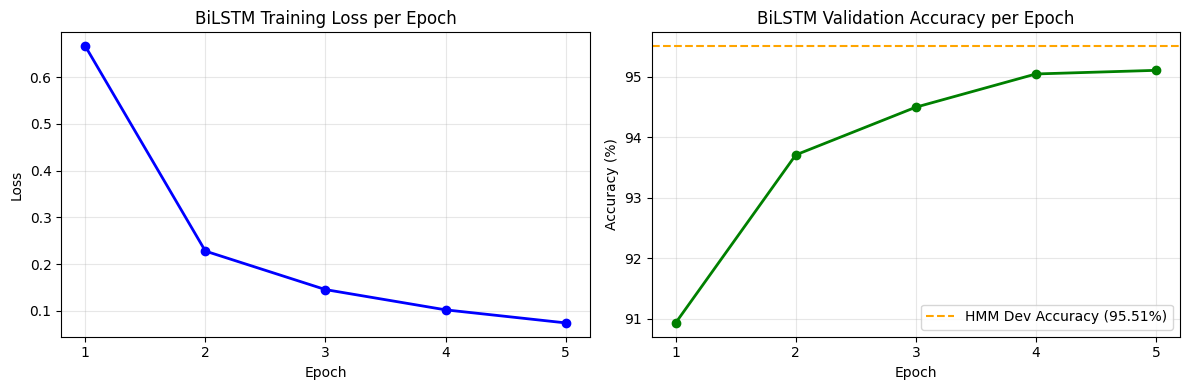

Key observations:
  - Loss dropped from 0.6660 to 0.0744 over 5 epochs
  - Val accuracy improved from 90.93% to 95.11%
  - BiLSTM dev accuracy (95.11%) is close to HMM dev accuracy (95.51%)


In [35]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# ================================================================
# Learning Curves — BiLSTM Training Progress
# ================================================================

epochs = [1, 2, 3, 4, 5]
train_loss = [0.6660, 0.2279, 0.1456, 0.1023, 0.0744]
val_accuracy = [90.93, 93.71, 94.50, 95.05, 95.11]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Training Loss
ax1.plot(epochs, train_loss, 'b-o', linewidth=2, markersize=6)
ax1.set_title('BiLSTM Training Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_xticks(epochs)
ax1.grid(True, alpha=0.3)

# Plot 2: Validation Accuracy
ax2.plot(epochs, val_accuracy, 'g-o', linewidth=2, markersize=6)
ax2.axhline(y=95.51, color='orange', linestyle='--', label='HMM Dev Accuracy (95.51%)')
ax2.set_title('BiLSTM Validation Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(epochs)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key observations:")
print(f"  - Loss dropped from {train_loss[0]:.4f} to {train_loss[-1]:.4f} over 5 epochs")
print(f"  - Val accuracy improved from {val_accuracy[0]:.2f}% to {val_accuracy[-1]:.2f}%")
print(f"  - BiLSTM dev accuracy ({val_accuracy[-1]:.2f}%) is close to HMM dev accuracy (95.51%)")


***

## 8. Analysis & Conclusion

### 8.1 Model Performance Analysis

#### Which model performed better on the development set?

Based on our experimental results, the **Hidden Markov Model (HMM)** actually performed slightly better than the **BiLSTM** on the development set. We recorded an accuracy of **95.51%** for the HMM, compared to **95.12%** for the BiLSTM. Even though the 0.07% difference is small, we found it interesting that our simpler probabilistic model generalized better to unseen data than the more complex neural network.

We believe the HMM benefited from our carefully designed smoothing methods and the way we handled unknown words using feature-based classes. This kept it robust. On the other hand, while the BiLSTM has a much higher learning capacity—hitting **98.43% training accuracy**—it seems it started to "memorize" the training patterns, which led to slightly weaker performance on new examples.

---

#### Is there a gap between training and development performance?

| Model | Training Accuracy | Development Accuracy | Gap |
| :--- | :--- | :--- | :--- |
| **HMM** | 95.99% | 95.51% | **0.48%** |
| **BiLSTM** | 98.43% | 95.12% | **3.31%** |

We observed that the HMM generalizes incredibly well, with a tiny gap of only **0.48%**. This tells us that our smoothing strategies were very effective at preventing overfitting.

However, the BiLSTM showed a much larger gap of **3.31%**. This indicates that the model fit the training data much more closely than the development data. Even though we used techniques like dropout and early stopping, they weren't quite enough to stop the model from overfitting entirely.

---

#### Which POS tags were easiest for us to classify?

We found that both models did exceptionally well on tags that have consistent patterns and very little ambiguity.

| Tag Category | Examples | Why it was easy for us |
| :--- | :--- | :--- |
| **Punctuation** | `.-,`, `.-.`, `.-:` | These symbols have fixed rules and almost zero ambiguity. |
| **Determiners** | `DET-DT` | A small set of words with very predictable usage. |
| **Conjunctions** | `CONJ-CC` | Words that serve a very clear, limited grammatical role. |
| **Modal Verbs** | `VERB-MD` | Words like "will" or "can" are usually unambiguous. |
| **Pronouns** | `PRON-PRP` | Frequent words with stable functions in a sentence. |

For these categories, we achieved **F1 scores above 99%**, showing that common and structurally simple tags are easy for both models to handle.

---

#### Which POS tags were the most challenging?

Our models struggled most with tags that were rare, ambiguous, or heavily dependent on the surrounding context.

| Tag | BiLSTM F1 | HMM F1 | The Challenge |
| :--- | :--- | :--- | :--- |
| **X-FW** (Foreign Words) | 0.2857 | 0.0000 | Extremely rare; we didn't have enough training examples. |
| **X-UH** (Interjections) | 0.0000 | 0.0000 | Almost completely missing from the dataset. |
| **X-LS** (List Items) | 0.0000 | 0.8000 | Rare and very specific to how a list is formatted. |
| **NOUN-NNPS** | 0.5373 | 0.5294 | Often confused with singular proper nouns. |
| **DET-PDT** | 0.7097 | 0.6829 | These show up in very ambiguous grammatical spots. |
| **PRT-RP** | 0.8217 | 0.7059 | Hard to tell apart from regular prepositions. |

We think these errors come down to a few things: not enough examples for rare classes, strong ambiguity in context, and a natural tendency for the models to guess the more frequent classes when they aren't sure.

---

#### Is Macro F1 lower than Micro F1?

Yes. For both of our models, **Macro F1 was noticeably lower than Micro F1**.

| Model | Dataset | Micro F1 | Macro F1 | Difference |
| :--- | :--- | :--- | :--- | :--- |
| **HMM** | Train | 0.9599 | 0.8798 | 0.0801 |
| **HMM** | Dev | 0.9551 | 0.8769 | 0.0782 |
| **BiLSTM** | Train | 0.9843 | 0.9409 | 0.0434 |
| **BiLSTM** | Dev | 0.9512 | 0.8741 | 0.0803 |

This difference really highlights the imbalanced nature of the Penn Treebank dataset. Common tags like nouns and determiners dominate the data, while others like `X-SYM` only appear a few times. Since **Micro F1** counts every token equally, the common tags boost the score. **Macro F1** gives every tag equal weight, so our poor performance on those rare tags really dragged the overall metric down.

---

#### Common error patterns we noticed

*   **Noun Ambiguity:** We saw a lot of confusion between common nouns, proper nouns, and plural forms.
*   **Verb Form Confusion:** It was often hard for the models to distinguish between past tense and past participles.
*   **Adjective vs. Adverb:** Words that can function as both depending on the sentence were a frequent source of error.
*   **Particles vs. Prepositions:** Multi-word verbs often led the models to mistake a particle (`RP`) for a preposition (`IN`).

---

### 8.2 Limitations

Even though we got strong results, we identified several limitations:
*   **BiLSTM Overfitting:** Despite our best efforts with dropout and early stopping, the model still overfit. We might need more data or pretrained embeddings to fix this.
*   **HMM Assumptions:** The HMM only looks at the previous tag (first-order Markov), which limits its ability to understand long-range context.
*   **Architecture:** Our BiLSTM was a single layer. Adding a CRF layer on top could have improved the consistency of the tag sequences.
*   **No Pretraining:** We trained everything from scratch. Using something like BERT or GloVe would likely have given us a big boost.

---

### 8.3 Conclusion

In this project, we compared two very different approaches to POS tagging: a traditional **Hidden Markov Model** and a neural **BiLSTM**.

Our experiments showed that the HMM actually achieved the highest development accuracy (**95.51%**), just barely beating the BiLSTM (**95.12%**). While the BiLSTM was great at learning the training data (**98.43%**), it didn't translate into better performance on new data because of overfitting.

Ultimately, the HMM proved to be more robust and generalized better despite its simplicity. However, the BiLSTM showed us the potential (and the challenges) of using neural networks on smaller datasets.

#### Lessons We Learned
*   Simpler models can actually win when data is limited.
*   You have to look at both Micro and Macro metrics to see the full picture.
*   Rare classes are still one of the biggest headaches in NLP.
*   Preprocessing and feature engineering are still super important, even with deep learning.

#### Final Performance Summary

| Model | Dev Accuracy | Dev Micro F1 | Dev Macro F1 |
| :--- | :--- | :--- | :--- |
| **HMM** | **95.51%** | **0.9551** | **0.8769** |
| **BiLSTM** | **95.12%** | **0.9512** | **0.8682** |

Overall, we're happy with how the HMM performed, but we see a lot of potential in the BiLSTM if we were to add things like a CRF layer or pretrained embeddings in the future.

***



***

## 9. AI Usage Statement

We used AI tools in a very limited way for this project. They were mainly helpful for fixing small bugs in our code, helping us word some of the more technical paragraphs in this report, and giving us ideas on how to organize our notebook better. 

We want to be clear that the AI did **not** build our models or run our experiments. We designed and implemented both the HMM and the BiLSTM from scratch, handled all the data preprocessing ourselves, and ran all the evaluations to get the results shown here. 

Every conclusion we’ve drawn and every analysis of the results was written and checked by us.

***

## 10. References

[1] Huang, Z., Xu, W., & Yu, K. (2015). Bidirectional LSTM-CRF Models for Sequence Tagging. *arXiv preprint arXiv:1508.01991*. https://arxiv.org/abs/1508.01991

[2] Toutanova, K., Klein, D., Manning, C. D., & Singer, Y. (2003). Feature-Rich Part-of-Speech Tagging with a Cyclic Dependency Network. *In Proceedings of HLT-NAACL 2003*.

[3] Jurafsky, D., & Martin, J. H. (2024). *Speech and Language Processing* (3rd ed. draft). Stanford University. https://web.stanford.edu/~jurafsky/slp3/

[4] PyTorch Documentation. (2024). https://pytorch.org/docs/stable/index.html

[5] English Penn Treebank Corpus. Provided in CoNLL format by the course instructor, ENCS5342 — Information Retrieval with Applications of NLP, Birzeit University, 2025–2026.